# Project Overview

This project develops a **machine learning framework to estimate the probability of a U.S. economic recession 12 months ahead** using macroeconomic indicators from the Federal Reserve Economic Data (FRED) database.

Macroeconomic systems evolve over time and are influenced by interactions between **monetary policy, inflation dynamics, labor markets, financial markets, and real economic activity**. Because these relationships often unfold with time delays, the project applies a **Long Short-Term Memory (LSTM)** neural network, a type of recurrent neural network designed to capture temporal dependencies in sequential data.

The dataset consists of several key macroeconomic indicators:

- Federal Funds Rate (monetary policy stance)
- Consumer Price Index (inflation)
- Unemployment Rate (labor market conditions)
- 10-Year Treasury Yield (financial market expectations)
- Industrial Production Index (real economic activity)

To make the data more suitable for modeling economic dynamics, the raw variables are transformed into **year-over-year changes, interest rate differentials, and yield curve measures**. These transformations help remove long-term trends and emphasize cyclical movements associated with economic expansions and downturns.

The modeling pipeline follows several steps:

1. Collect and align macroeconomic time-series data from FRED
2. Engineer economically meaningful features (YoY changes and spreads)
3. Normalize variables using MinMax scaling
4. Construct sequential inputs using a 12-month lookback window
5. Train an LSTM-based classification model
6. Estimate recession probabilities and evaluate performance using classification metrics

By shifting the recession indicator forward by **12 months**, the model learns to associate current macroeconomic conditions with **future recession outcomes**, turning the task into a forward-looking forecasting problem.

The objective of the project is not only to build a predictive model, but also to explore how **machine learning techniques can be applied to macroeconomic forecasting**, particularly in identifying early warning signals of economic downturns.

# Macroeconomic Feature Description (FRED Dataset)

This project uses macroeconomic time-series data from the Federal Reserve Economic Data (FRED) database to model **recession probability** using a multivariate LSTM model.

Instead of using raw macroeconomic levels directly, the variables are transformed into features that better capture **macroeconomic dynamics** such as inflation pressure, economic growth, monetary tightening, labor market deterioration, financial market repricing, and yield curve conditions.

The target variable is defined as a **12-month-ahead recession indicator**, making this a true forecasting problem.

---

## 1. Inflation, Year-over-Year (`inflation_yoy`)

**Source Variable:** Consumer Price Index (`CPIAUCSL`)  
**Transformation:** `pct_change(12) * 100`

**Description:**  
This feature measures the year-over-year percentage change in the Consumer Price Index, which serves as a proxy for inflation.

**Economic Role**
- Captures inflation pressure in the economy
- Reflects changes in consumer purchasing power
- Influences central bank policy decisions

**Macroeconomic Impact**

Higher inflation:
- Increases the likelihood of monetary tightening
- Reduces real purchasing power
- Can slow future economic growth

Lower inflation:
- Supports accommodative monetary policy
- Reduces pressure on borrowing costs

**Why Used in the Model**

The raw CPI level trends upward over time, so the year-over-year inflation rate is used instead to capture inflation dynamics in a more stationary and interpretable form.

---

## 2. Industrial Production Growth, Year-over-Year (`industrial_growth_yoy`)

**Source Variable:** Industrial Production Index (`INDPRO`)  
**Transformation:** `pct_change(12) * 100`

**Description:**  
This feature measures the year-over-year growth rate of industrial production, representing changes in real economic activity.

**Economic Role**
- Proxy for economic expansion or contraction
- Reflects production-side momentum in the economy
- Closely tied to the business cycle

**Macroeconomic Impact**

Higher industrial growth:
- Indicates stronger economic activity
- Supports employment and income growth
- Reduces recession risk

Lower industrial growth:
- Signals economic slowdown
- Often precedes higher unemployment
- Increases recession risk

**Why Used in the Model**

The raw industrial production index has a long-term upward trend, so year-over-year growth is used to better capture cyclical movements in real activity.

---

## 3. Federal Funds Rate Change, Year-over-Year (`fed_funds_change_yoy`)

**Source Variable:** Federal Funds Rate (`FEDFUNDS`)  
**Transformation:** `diff(12)`

**Description:**  
This feature measures the change in the Federal Funds Rate over the past 12 months.

**Economic Role**
- Captures the direction and magnitude of monetary policy changes
- Reflects whether the central bank has been tightening or easing policy

**Macroeconomic Impact**

Positive change:
- Indicates monetary tightening
- Raises borrowing costs
- May slow future demand and growth

Negative change:
- Indicates monetary easing
- Supports liquidity and borrowing
- May stimulate economic activity

**Why Used in the Model**

The absolute level of interest rates is less informative than the change in policy stance. This feature captures the cumulative tightening or easing over the previous year.

---

## 4. Unemployment Rate Change, Year-over-Year (`unemployment_change_yoy`)

**Source Variable:** Unemployment Rate (`UNRATE`)  
**Transformation:** `diff(12)`

**Description:**  
This feature measures how much the unemployment rate has changed compared with the same month one year earlier.

**Economic Role**
- Captures labor market deterioration or improvement
- Reflects the strength of the business cycle

**Macroeconomic Impact**

Rising unemployment:
- Signals weakening labor market conditions
- Suggests slowing demand and business activity
- Increases recession risk

Falling unemployment:
- Indicates a strengthening labor market
- Supports income growth and consumption
- Reduces recession risk

**Why Used in the Model**

The change in unemployment is often more informative than the unemployment level itself when identifying turning points in the economy.

---

## 5. 10-Year Treasury Yield Change, Year-over-Year (`ten_year_yield_change_yoy`)

**Source Variable:** 10-Year Treasury Yield (`DGS10`)  
**Transformation:** `diff(12)`

**Description:**  
This feature measures the 12-month change in the 10-year U.S. Treasury yield.

**Economic Role**
- Captures changes in long-term market expectations
- Reflects shifts in expected inflation, growth, and future policy rates

**Macroeconomic Impact**

Rising long-term yields:
- May reflect stronger growth expectations or inflation concerns
- Tighten financial conditions

Falling long-term yields:
- Often reflect weaker growth expectations
- May indicate rising recession fears

**Why Used in the Model**

Long-term yields are forward-looking market variables. Using yearly changes helps capture financial market repricing over time.

---

## 6. Yield Curve Spread (`yield_spread`)

**Source Variables:** 10-Year Treasury Yield (`DGS10`) and Federal Funds Rate (`FEDFUNDS`)  
**Transformation:** `ten_year_yield - fed_funds`

**Description:**  
This feature measures the difference between long-term and short-term interest rates, representing the slope of the yield curve.

**Economic Role**
- Summarizes market expectations about future growth and policy
- One of the most widely used indicators of recession risk

**Macroeconomic Impact**

Positive spread:
- Indicates a normal upward-sloping yield curve
- Usually associated with stable or expanding economic conditions

Low or negative spread:
- Indicates a flat or inverted yield curve
- Historically associated with elevated recession risk

**Why Used in the Model**

The yield spread is one of the most powerful macro-financial recession indicators and captures information not fully reflected in the other variables.

---

## 7. Recession Target, 12 Months Ahead (`recession_target`)

**Source Variable:** U.S. Recession Indicator (`USREC`)  
**Transformation:** `shift(-12)`

**Description:**  
This target variable indicates whether the U.S. economy will be in recession **12 months in the future**.

**Economic Role**
- Converts the problem into a forward-looking classification task
- Allows the model to estimate recession probability ahead of time

**Interpretation**
- `0` = no recession in 12 months
- `1` = recession in 12 months

**Why Used in the Model**

Without shifting the recession label forward, the model would only classify current conditions. By using a 12-month-ahead target, the model becomes a true forecasting model for recession risk.

# Feature Description

| Feature                | FRED Code  | Unit                       | Meaning                                          |
| ---------------------- | ---------- | -------------------------- | ------------------------------------------------ |
| Federal Funds Rate     | `FEDFUNDS` | Percent (%)                | Annualized interest rate between banks           |
| Consumer Price Index   | `CPIAUCSL` | Index (1982–84 = 100 base) | Price level relative to base period              |
| Unemployment Rate      | `UNRATE`   | Percent (%)                | Percentage of labor force unemployed             |
| 10-Year Treasury Yield | `DGS10`    | Percent (%)                | Annualized yield of 10-year government bond      |
| Industrial Production  | `INDPRO`   | Index (2017 = 100 base)    | Level of industrial output relative to base year |


# Import relevant libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    mean_squared_error
)
from sklearn.utils import class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Pull data from Fred API

In [36]:
from fredapi import Fred

fred = Fred(api_key="1e5200114afbc75d1132716f51dbc1c9")

fed_funds = fred.get_series("FEDFUNDS")
cpi = fred.get_series("CPIAUCSL")
unemployment = fred.get_series("UNRATE")
ten_year_yield = fred.get_series("DGS10")
industrial_production = fred.get_series("INDPRO")
recession = fred.get_series("USREC")

# Create DataFrame

In [37]:
df = pd.concat([
    fed_funds,
    cpi,
    unemployment,
    ten_year_yield,
    industrial_production,
    recession
], axis=1)

df.columns = [
    "fed_funds",
    "cpi",
    "unemployment",
    "ten_year_yield",
    "industrial_production",
    "recession"
]

C:\Users\MSI STEALTH\AppData\Local\Temp\ipykernel_21780\1818133849.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df = pd.concat([


In [38]:
df.info()

df.head()

<class 'pandas.DataFrame'>
DatetimeIndex: 18251 entries, 1854-12-01 to 2026-03-09
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   fed_funds              860 non-null    float64
 1   cpi                    948 non-null    float64
 2   unemployment           937 non-null    float64
 3   ten_year_yield         16029 non-null  float64
 4   industrial_production  1285 non-null   float64
 5   recession              2055 non-null   float64
dtypes: float64(6)
memory usage: 998.1 KB


,fed_funds,cpi,unemployment,ten_year_yield,industrial_production,recession
1854-12-01,NaN,NaN,NaN,NaN,NaN,1.0
1855-01-01,NaN,NaN,NaN,NaN,NaN,0.0
1855-02-01,NaN,NaN,NaN,NaN,NaN,0.0
1855-03-01,NaN,NaN,NaN,NaN,NaN,0.0
1855-04-01,NaN,NaN,NaN,NaN,NaN,0.0


In [39]:
df.tail()

,fed_funds,cpi,unemployment,ten_year_yield,industrial_production,recession
2026-03-03,NaN,NaN,NaN,4.06,NaN,NaN
2026-03-04,NaN,NaN,NaN,4.09,NaN,NaN
2026-03-05,NaN,NaN,NaN,4.13,NaN,NaN
2026-03-06,NaN,NaN,NaN,4.15,NaN,NaN
2026-03-09,NaN,NaN,NaN,4.12,NaN,NaN


# Data Cleaning

## Change index to monthly

In [40]:
df_model = df.sort_index().asfreq("MS")

In [41]:
df_model.tail()

,fed_funds,cpi,unemployment,ten_year_yield,industrial_production,recession
2025-11-01,3.88,325.063,4.5,NaN,101.3775,0.0
2025-12-01,3.72,326.031,4.4,4.09,101.6296,0.0
2026-01-01,3.64,326.588,4.3,NaN,102.3412,0.0
2026-02-01,3.64,NaN,4.4,NaN,NaN,0.0
2026-03-01,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
df_model.isna().sum()

fed_funds                1196
cpi                      1108
unemployment             1119
ten_year_yield           1565
industrial_production     771
recession                   1
dtype: int64

## Change all samples to monthly unit

In [43]:
# Force monthly alignment
fed_funds_m = fed_funds.resample("MS").first()
cpi_m = cpi.resample("MS").first()
unemployment_m = unemployment.resample("MS").first()
industrial_production_m = industrial_production.resample("MS").first()

# DGS10 is daily, so convert to monthly
ten_year_yield_m = ten_year_yield.resample("MS").mean()

# Recession indicator (already monthly but we align it anyway)
recession_m = recession.resample("MS").first()

# Combine all features
df_model = pd.concat(
    [
        fed_funds_m,
        cpi_m,
        unemployment_m,
        ten_year_yield_m,
        industrial_production_m,
        recession_m
    ],
    axis=1
)

df_model.columns = [
    "fed_funds",
    "cpi",
    "unemployment",
    "ten_year_yield",
    "industrial_production",
    "recession"
]

C:\Users\MSI STEALTH\AppData\Local\Temp\ipykernel_21780\3917604358.py:14: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_model = pd.concat(


In [44]:
df_model_dc = df_model.copy()

## Drop all samples without recorded features for better modelling

In [45]:
df_model_dc = df_model.dropna()

In [46]:
df_model_dc.info()

df_model_dc.head()

<class 'pandas.DataFrame'>
DatetimeIndex: 768 entries, 1962-01-01 to 2026-01-01
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   fed_funds              768 non-null    float64
 1   cpi                    768 non-null    float64
 2   unemployment           768 non-null    float64
 3   ten_year_yield         768 non-null    float64
 4   industrial_production  768 non-null    float64
 5   recession              768 non-null    float64
dtypes: float64(6)
memory usage: 42.0 KB


,fed_funds,cpi,unemployment,ten_year_yield,industrial_production,recession
1962-01-01,2.15,30.04,5.8,4.083182,24.6925,0.0
1962-02-01,2.37,30.11,5.5,4.039444,25.0964,0.0
1962-03-01,2.85,30.17,5.6,3.930455,25.2311,0.0
1962-04-01,2.78,30.21,5.6,3.843000,25.2850,0.0
1962-05-01,2.36,30.24,5.5,3.873636,25.2580,0.0


# EDA

In [47]:
df_model_dc.describe(include='all')

,fed_funds,cpi,unemployment,ten_year_yield,industrial_production,recession
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,4.858802,146.888521,5.855078,5.823620,70.273637,0.110677
std,3.648249,84.387176,1.717097,2.940880,25.591869,0.313936
min,0.050000,30.040000,3.400000,0.623636,24.692500,0.000000
25%,1.995000,62.600000,4.600000,3.884286,47.918500,0.000000
50%,4.795000,146.300000,5.600000,5.471158,66.639350,0.000000
75%,6.560000,217.365500,7.000000,7.529330,97.177300,0.000000
max,19.100000,326.588000,14.800000,15.323810,104.100400,1.000000


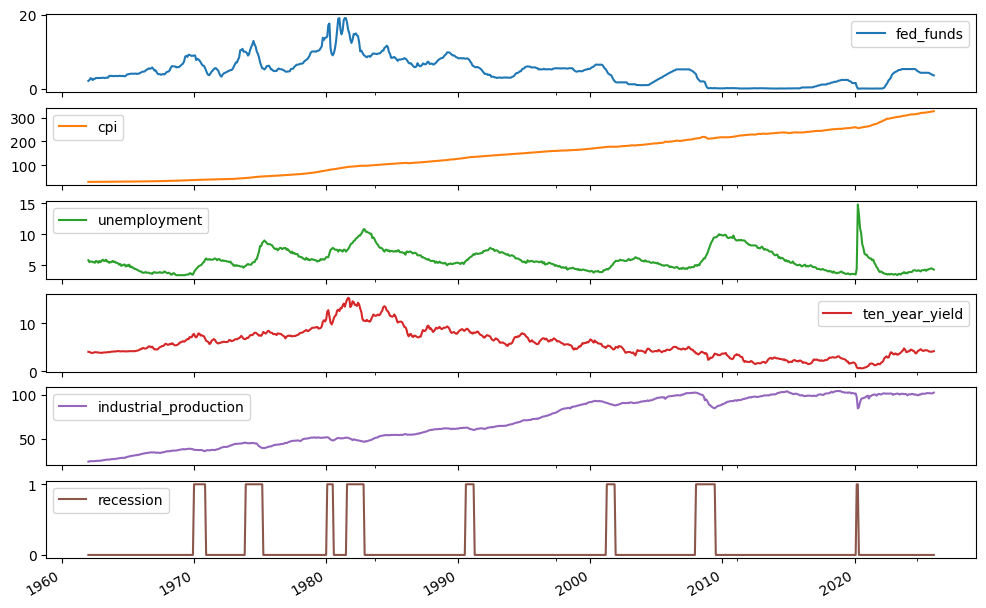

In [48]:
df_model_dc.plot(subplots=True, figsize=(12,8))
plt.show()

# Insights - Exploratory Data Analysis: Macroeconomic Time Series

The chart above visualizes the historical evolution of five key macroeconomic indicators obtained from the FRED database:

- Federal Funds Rate (`FEDFUNDS`)
- Consumer Price Index (`CPIAUCSL`)
- Unemployment Rate (`UNRATE`)
- 10-Year Treasury Yield (`DGS10`)
- Industrial Production Index (`INDPRO`)

The data begins in the early 1960s after aligning all series to the period where they are simultaneously available.

---

# 1. Monetary Policy Cycles (Federal Funds Rate)

The Federal Funds Rate displays clear **monetary policy regimes** over time.

Key observations:

- The **late 1970s and early 1980s** show extremely high interest rates, peaking near 20%.  
  This period corresponds to the **Volcker tightening**, when the Federal Reserve aggressively raised rates to combat high inflation.

- After the early 1980s, interest rates gradually declined as inflation stabilized.

- During the **2008 Global Financial Crisis**, the Federal Reserve reduced rates to near zero to stimulate economic activity.

- Another near-zero rate regime occurred during the **COVID-19 pandemic (2020)**.

- More recently, the rate increased sharply again as central banks responded to elevated inflation.

These regime changes illustrate how monetary policy responds to macroeconomic conditions.

---

# 2. Inflation Trend (Consumer Price Index)

The Consumer Price Index shows a **strong upward trend over time**.

Important characteristics:

- CPI is an **index**, meaning it represents the relative price level rather than the inflation rate itself.
- The long upward trajectory reflects cumulative inflation over decades.
- Because CPI is non-stationary, its raw level is less suitable for modeling.

For machine learning models, CPI is typically transformed into:

- **Year-over-year inflation**
- **Month-over-month inflation**

These transformations remove the long-term trend and provide a more stable signal.

---

# 3. Labor Market Cycles (Unemployment Rate)

The unemployment rate clearly reflects **business cycle dynamics**.

Major spikes in unemployment correspond to well-known economic recessions:

| Period | Economic Event |
|------|----------------|
| 1974–1975 | Oil crisis recession |
| 1981–1982 | Volcker disinflation recession |
| 1990–1991 | Early 1990s recession |
| 2008–2009 | Global Financial Crisis |
| 2020 | COVID-19 pandemic shock |

Unemployment tends to rise sharply during economic downturns and gradually decline during expansions.

This variable therefore acts as a strong indicator of **economic health and recession risk**.

---

# 4. Long-Term Interest Rate (10-Year Treasury Yield)

The 10-year Treasury yield reflects **market expectations about future economic conditions**.

Several structural regimes are visible:

- Rising yields from the 1960s through the early 1980s due to high inflation.
- A long downward trend from the 1980s to the late 2010s, often referred to as the **multi-decade bond bull market**.
- Recent increases driven by renewed inflation pressures.

Because long-term yields incorporate expectations about future inflation and economic growth, they provide a **forward-looking financial signal**.

---

# 5. Industrial Production (Real Economic Activity)

The Industrial Production Index shows a long-term upward trend reflecting **economic growth and technological progress**.

However, cyclical declines are visible during recessions:

- Early 1980s recession
- 2008 Global Financial Crisis
- 2020 pandemic contraction

Industrial production therefore captures **real economic momentum**, complementing financial and policy variables.

---

# 6. Key Observations from the Dataset

Several important insights emerge from the visualization:

1. **Macroeconomic regimes exist**  
   Variables move in cycles corresponding to economic expansions and contractions.

2. **Policy responds to inflation and growth conditions**  
   Changes in the Federal Funds Rate appear to follow inflationary pressures and economic downturns.

3. **Financial markets incorporate expectations**  
   Long-term Treasury yields reflect expectations about inflation and economic activity.

4. **Real economic activity follows cyclical patterns**  
   Industrial production rises during expansions and contracts during recessions.

---

# 7. Implications for Modeling

These variables interact with each other over time and often exhibit **lagged relationships**. For example:

- Rising inflation may lead to higher policy interest rates.
- Tightening monetary policy may slow economic growth later.
- Slower growth may increase unemployment.

Because these interactions unfold across multiple time periods, a **sequence-based model such as LSTM** is well suited to capture the temporal dependencies within the macroeconomic system.

The next step in the analysis will involve transforming the raw macroeconomic variables into stationary features (e.g., inflation rates and growth rates) before constructing time-series sequences for the LSTM model.

## Plot YoY Change

Raw macroeconomic variables often contain long-term trends and structural shifts. If used directly, machine learning models may learn **time trends rather than meaningful economic relationships**. To address this, the raw variables are transformed into **year-over-year (YoY) changes or differences**, which better capture economic dynamics.

The CPI and Industrial Production series are converted to **YoY percentage changes** using `.pct_change(12)` because these variables are **index levels** that trend upward over time. The transformation measures inflation and economic growth relative to the same month in the previous year.

Interest rates and unemployment are already expressed as **percentages**, so using percent change would produce misleading results. Instead, `.diff(12)` is used to compute the **absolute change over one year**, which reflects changes in monetary policy stance, labor market conditions, and financial market expectations.

These transformations help remove long-term trends, improve stationarity, and highlight the interactions between inflation, economic growth, monetary policy, and labor markets—making the dataset more suitable for time-series modeling methods such as LSTM.

**Target Variable**: Recession 12 Months Ahead

To turn the problem into a **forecasting task**, the recession indicator is shifted **12 months into the future**:

df_yoy["recession_target"] = df_model_dc["recession"].`shift(-12)`

## Change unit of features for modelling and define **Target**

In [49]:
df_yoy = pd.DataFrame(index=df_model_dc.index)

# YoY inflation
df_yoy["inflation_yoy"] = df_model_dc["cpi"].pct_change(12) * 100

# YoY Industrial production growth
df_yoy["industrial_growth_yoy"] = df_model_dc["industrial_production"].pct_change(12) * 100

# Rate changes over 1 year
df_yoy["fed_funds_change_yoy"] = df_model_dc["fed_funds"].diff(12)
df_yoy["unemployment_change_yoy"] = df_model_dc["unemployment"].diff(12)
df_yoy["ten_year_yield_change_yoy"] = df_model_dc["ten_year_yield"].diff(12)

# TARGET VARIABLE
# Predict recession 12 months ahead
df_yoy["recession_target"] = df_model_dc["recession"].shift(-12)

In [53]:
df_yoy = df_yoy.dropna()
df_yoy.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 744 entries, 1963-01-01 to 2024-12-01
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   inflation_yoy              744 non-null    float64
 1   industrial_growth_yoy      744 non-null    float64
 2   fed_funds_change_yoy       744 non-null    float64
 3   unemployment_change_yoy    744 non-null    float64
 4   ten_year_yield_change_yoy  744 non-null    float64
 5   recession_target           744 non-null    float64
dtypes: float64(6)
memory usage: 40.7 KB


### Sanity check for Target

In [55]:
df_yoy["recession_target"].value_counts()

recession_target
0.0    659
1.0     85
Name: count, dtype: int64

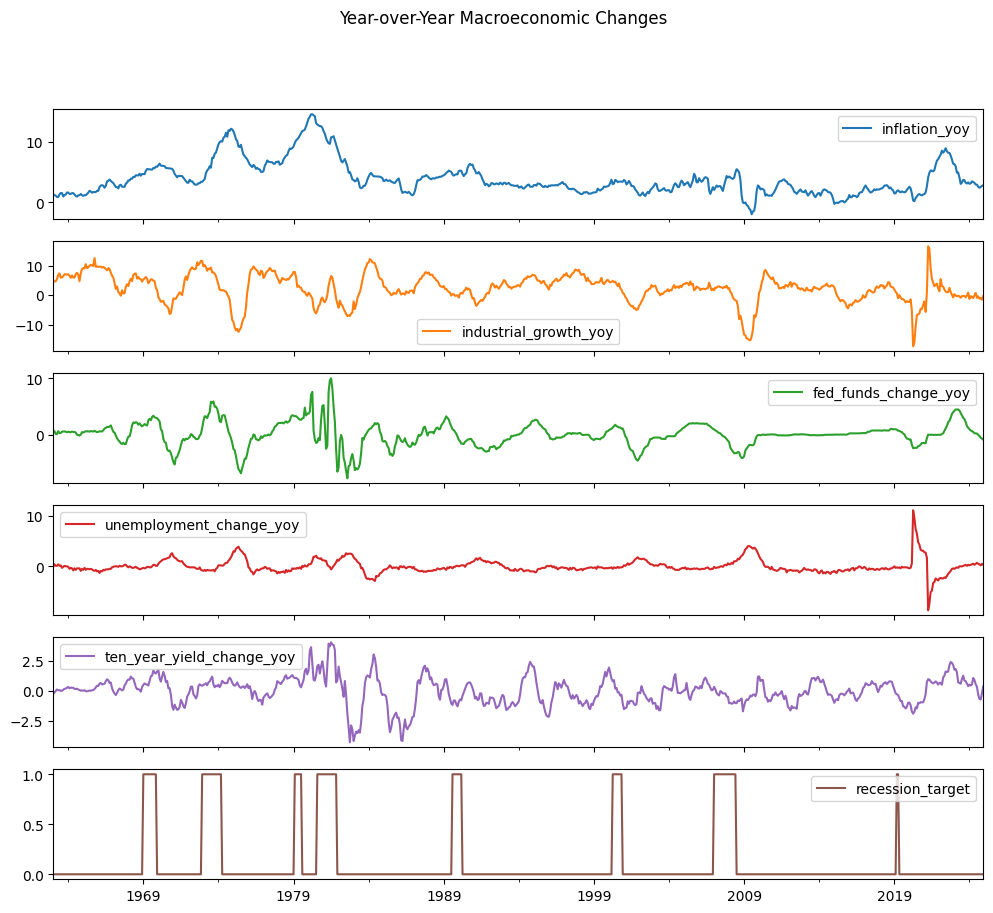

In [56]:
df_yoy.plot(subplots=True, figsize=(12,10), sharex=True)

plt.suptitle("Year-over-Year Macroeconomic Changes")
plt.tight_layout
plt.show()

# Insights - Year-over-Year Macroeconomic Changes

The chart above shows the **year-over-year changes** in key macroeconomic indicators.  
Transforming the data into YoY changes removes long-term trends and highlights the **cyclical dynamics of the economy**, which are more relevant for time-series modeling.

The following insights can be observed from the visualization.

---

# 1. Inflation Dynamics

The inflation series exhibits several distinct regimes:

- **1970s–early 1980s:** Inflation surged dramatically, peaking near 15%.  
  This period corresponds to the **stagflation crisis**, driven by oil shocks and loose monetary policy.

- **Early 1980s:** Inflation fell sharply following aggressive interest rate hikes by the Federal Reserve under **Paul Volcker**.

- **1990–2019:** Inflation remained relatively stable, typically between **1%–4%**, reflecting the period often referred to as the **Great Moderation**.

- **2021–2022:** Inflation rose again due to pandemic-related supply shocks, fiscal stimulus, and supply chain disruptions.

These inflation cycles illustrate how macroeconomic shocks propagate through the economy.

---

# 2. Industrial Production Growth

Industrial production growth reflects **real economic activity**.

Key observations:

- Growth fluctuates around a long-term average of roughly **2–5%**.
- Large negative shocks correspond to major economic crises:
  - **1982 recession**
  - **2008 Global Financial Crisis**
  - **2020 COVID-19 economic shutdown**

The pandemic period shows the largest contraction in modern history, followed by a sharp recovery.

Industrial production therefore serves as a strong proxy for **economic momentum**.

---

# 3. Monetary Policy Changes

The year-over-year change in the Federal Funds Rate highlights periods of **monetary tightening and easing**.

Major tightening cycles appear in:

- **Late 1970s–early 1980s:** aggressive rate increases to combat inflation
- **Early 2000s**
- **Mid-2000s before the financial crisis**
- **2022 inflation tightening cycle**

Periods where the change approaches zero represent **stable monetary policy regimes**, such as the long low-rate period after the 2008 crisis.

These policy shifts often precede changes in economic activity.

---

# 4. Labor Market Changes

Changes in unemployment reveal the **timing of recessions**.

Sharp increases in unemployment occur during:

- **1982 recession**
- **2009 financial crisis**
- **2020 pandemic**

The spike in 2020 is historically unprecedented because the economic shutdown occurred abruptly due to public health restrictions.

Unemployment typically rises quickly during downturns but declines gradually during recoveries.

---

# 5. Long-Term Interest Rate Changes

The change in the 10-year Treasury yield reflects **financial market expectations** regarding:

- inflation
- economic growth
- monetary policy

Yield movements are generally more volatile than macroeconomic indicators because they incorporate **forward-looking market information**.

Large yield adjustments often occur during:

- inflation shocks
- monetary policy shifts
- financial crises

---

# 6. Macroeconomic Interactions

Several relationships can be inferred from the chart:

- Rising inflation is often followed by **monetary tightening**.
- Economic downturns lead to **falling industrial production and rising unemployment**.
- Interest rate adjustments occur as central banks attempt to stabilize inflation and economic growth.

These interactions create **temporal dependencies across variables**, making the dataset well-suited for sequence models.

---

# 7. Implications for LSTM Modeling

The LSTM model will attempt to learn patterns in how macroeconomic variables evolve over time.  
Because the data has been transformed into year-over-year changes, the model can focus on **economic dynamics rather than long-term trends**.

Examples of patterns the model may learn include:

- Inflation shocks leading to future interest rate increases
- Economic slowdowns leading to rising unemployment
- Monetary tightening preceding declines in industrial production

Capturing these temporal relationships is one of the strengths of recurrent neural networks such as LSTM.

## Correlation analysis

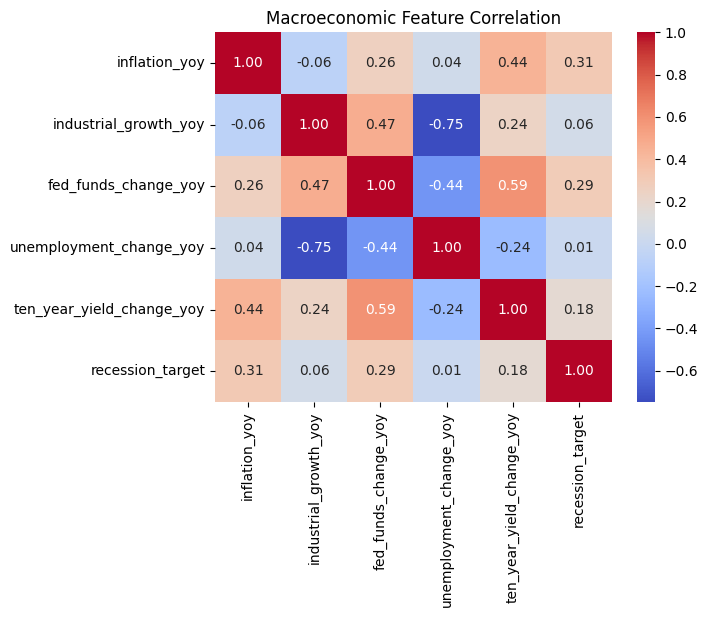

In [57]:
sns.heatmap(
    df_yoy.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Macroeconomic Feature Correlation")
plt.show()

## Macroeconomic Feature Correlation – Insights

The heatmap above shows the pairwise correlation between the transformed macroeconomic features.  
These correlations provide a useful sanity check and help verify that the relationships in the dataset align with well-known macroeconomic dynamics.

---

### 1. Industrial Growth vs Unemployment (-0.75)

The strongest relationship in the dataset is the negative correlation between industrial growth and unemployment.

Interpretation:

- When **industrial production grows**, firms increase output and demand more labor.
- As a result, **unemployment tends to decline**.

Conversely:

- When **industrial production contracts**, firms reduce output and may lay off workers.
- This leads to **rising unemployment**.

This relationship is consistent with **Okun’s Law**, which states that economic growth and unemployment move in opposite directions.

---

### 2. Fed Funds Change vs 10-Year Yield Change (0.59)

There is a strong positive relationship between changes in the Federal Funds Rate and changes in the 10-year Treasury yield.

Interpretation:

- When the **Federal Reserve raises policy rates**, financial markets adjust expectations for future interest rates.
- As a result, **long-term bond yields often increase as well**.

This reflects the transmission of **monetary policy into financial markets**.

---

### 3. Inflation vs Long-Term Yields (0.44)

Inflation shows a moderate positive correlation with changes in the 10-year Treasury yield.

Economic reasoning:

- Higher inflation erodes the purchasing power of fixed-income returns.
- Investors demand **higher yields** to compensate for inflation risk.

Therefore:
inflation ↑ -> bond yields ↑

---

### 4. Fed Funds vs Unemployment (-0.44)

There is a moderate negative relationship between changes in unemployment and changes in the policy rate.

Interpretation:

- When **unemployment rises**, central banks often **cut interest rates** to stimulate the economy.
- When **labor markets are strong**, central banks may raise rates to prevent overheating.

This reflects the role of monetary policy in stabilizing economic cycles.

---

### 5. Industrial Growth vs Fed Funds Change (0.47)

There is a moderate positive relationship between economic growth and changes in the Federal Funds Rate.

Interpretation:

- When the economy grows strongly, central banks may **tighten monetary policy** to prevent excessive inflation.

This reflects the **countercyclical nature of monetary policy**.

---

### 6. Inflation vs Industrial Growth (-0.06)

The correlation between inflation and industrial growth is weak.

This is expected because inflation can be influenced by multiple factors such as:

- supply shocks
- energy prices
- monetary policy
- inflation expectations

As a result, inflation does not always move directly with real economic activity.

---

## Important Limitation

The heatmap shows **contemporaneous correlations**, meaning relationships between variables at the same time period.

However, macroeconomic relationships often occur with **time lags**.

Examples:

- Rising inflation may lead to **interest rate increases several months later**.
- Monetary tightening may slow economic growth **after a delay**.

Because of these lagged effects, sequence-based models such as **LSTM** are well suited for capturing the temporal structure of macroeconomic data.

---

## Conclusion

The correlation structure in the dataset aligns with established macroeconomic relationships:

- Economic growth and unemployment move in opposite directions.
- Monetary policy responds to inflation and economic activity.
- Financial markets incorporate expectations about inflation and policy.

## Feature Engineering

**Yield Curve Spread**

The **yield curve spread** measures the difference between long-term and short-term interest rates.  
In this project, it is defined as the difference between the **10-year Treasury yield** and the **Federal Funds Rate**.

**Economic Relevance**
The yield spread reflects the slope of the yield curve, which captures market expectations about future economic conditions.

In a healthy economy, long-term interest rates are usually higher than short-term rates because investors demand compensation for:

- inflation risk

- economic uncertainty

- the opportunity cost of locking funds for longer periods

- This results in a positive yield spread.


In [73]:
df_yoy["yield_spread"] = df_model["ten_year_yield"] - df_model["fed_funds"]

df_yoy.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 744 entries, 1963-01-01 to 2024-12-01
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   inflation_yoy              744 non-null    float64
 1   industrial_growth_yoy      744 non-null    float64
 2   fed_funds_change_yoy       744 non-null    float64
 3   unemployment_change_yoy    744 non-null    float64
 4   ten_year_yield_change_yoy  744 non-null    float64
 5   recession_target           744 non-null    float64
 6   yield_spread               744 non-null    float64
dtypes: float64(7)
memory usage: 46.5 KB


# Model Preparation

## Define X & y

In [74]:
feature_cols = [
    "inflation_yoy",
    "industrial_growth_yoy",
    "fed_funds_change_yoy",
    "unemployment_change_yoy",
    "ten_year_yield_change_yoy",
    "yield_spread"
]

target_col = "recession_target"

X_df = df_yoy[feature_cols].copy()
y_df = df_yoy[target_col].copy()

print(X_df.shape)
print(y_df.shape)
print(y_df.value_counts())

(744, 6)
(744,)
recession_target
0.0    659
1.0     85
Name: count, dtype: int64


## Feature Scaling

Macroeconomic features in the dataset exist on **different numerical scales**. For example, inflation and unemployment are measured in percentages, while industrial production is an index and interest rates may vary within smaller ranges. Without scaling, variables with larger numeric magnitudes could disproportionately influence the learning process.

To address this, **MinMaxScaler** is applied to normalize each feature into the range:

\[
[0, 1]
\]

This scaling technique preserves the **relative relationships and temporal patterns** in the data while ensuring that all variables contribute proportionally during model training.

Feature scaling is particularly important for **neural network models such as LSTM**, because gradient-based optimization algorithms converge more efficiently when input variables are on comparable scales. Normalized inputs help stabilize training, improve numerical performance, and reduce the risk of certain features dominating the learning process.

In [75]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X_df)

X_scaled_df = pd.DataFrame(
    X_scaled,
    index=X_df.index,
    columns=X_df.columns
)

X_scaled_df.head()

,inflation_yoy,industrial_growth_yoy,fed_funds_change_yoy,unemployment_change_yoy,ten_year_yield_change_yoy,yield_spread
1963-01-01,0.198798,0.662635,0.478261,0.434343,0.482436,0.716606
1963-02-01,0.192591,0.647541,0.470356,0.459596,0.498293,0.717328
1963-03-01,0.186436,0.649950,0.442123,0.444444,0.512366,0.719978
1963-04-01,0.172346,0.671653,0.441558,0.444444,0.528056,0.731789
1963-05-01,0.172292,0.712760,0.470920,0.459596,0.519405,0.718186


##  Create Time Sequences

LSTM models are designed to learn patterns from **sequential data**, meaning the model must observe a **window of past observations** rather than a single point in time. To enable this, the dataset is transformed into **time sequences** using a rolling window approach.

A **lookback window of 12 months** is used

In [76]:
lookback = 12

X = []
y = []
dates = []

for i in range(lookback, len(X_scaled_df)):
    X.append(X_scaled_df.iloc[i - lookback:i].values)
    y.append(y_df.iloc[i])
    dates.append(X_scaled_df.index[i])

X = np.array(X)
y = np.array(y)
dates = np.array(dates)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (732, 12, 6)
y shape: (732,)


## Train/Test Split

In [77]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

dates_train = dates[:train_size]
dates_test = dates[train_size:]

print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes:", X_test.shape, y_test.shape)

Train shapes: (585, 12, 6) (585,)
Test shapes: (147, 12, 6) (147,)


## Check Target imbalance

In [78]:
print("Train class distribution:")
print(pd.Series(y_train).value_counts(normalize=True))

print("Test class distribution:")
print(pd.Series(y_test).value_counts(normalize=True))

Train class distribution:
0.0    0.85812
1.0    0.14188
Name: proportion, dtype: float64
Test class distribution:
0.0    0.986395
1.0    0.013605
Name: proportion, dtype: float64


## Build LSTM model

A multivariate **Long Short-Term Memory (LSTM)** network is used because the task involves **sequential macroeconomic data** rather than independent observations. Recession risk does not depend only on the current month’s macro conditions, but also on how inflation, growth, labor markets, interest rates, and the yield curve have evolved over time.

The model architecture is designed as a **binary sequence classifier**:

- An **Input layer** receives sequences of shape `(12, 6)`, representing **12 months of macroeconomic history across 6 engineered features**
- The first **LSTM layer** with 32 units returns sequences so the next recurrent layer can continue learning temporal dependencies
- A **Dropout layer** with rate `0.2` is added to reduce overfitting by randomly dropping a fraction of units during training
- A second **LSTM layer** with 16 units summarizes the sequence into a compact representation
- Another **Dropout layer** is used for additional regularization
- A final **Dense layer** with **sigmoid activation** outputs a value between **0 and 1**, interpreted as the predicted **probability of recession**

### Why this architecture is suitable

This architecture allows the model to learn:

- short- and medium-term macroeconomic patterns
- delayed effects of monetary policy
- interactions between inflation, labor markets, and financial variables
- nonlinear sequence behavior before recessions

The model is compiled with:

- **Adam optimizer**, which is effective for gradient-based training in neural networks
- **Binary cross-entropy loss**, because the target is a binary recession indicator
- **Accuracy** as a basic training metric, although additional metrics such as precision, recall, F1-score, and ROC-AUC are more informative for this imbalanced classification problem

Overall, this LSTM architecture is intended to capture how macroeconomic conditions evolve over time and translate those temporal patterns into a **forward-looking recession probability estimate**.

In [79]:
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(32, return_sequences=True),
    Dropout(0.2),
    LSTM(16),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 12, 32)         │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,145 (31.82 KB)

 Trainable params: 8,145 (31.82 KB)

 Non-trainable params: 0 (0.00 B)

## Add early stopping to prevent overfitting

In [80]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

## Adjust class_weight to account for Target imbalance

In [81]:
weights = class_weight.compute_class_weight(
    "balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    0: weights[0],
    1: weights[1]
}

## Train model

In [82]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.4791 - loss: 0.6759 - val_accuracy: 0.8644 - val_loss: 0.6067
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6483 - loss: 0.6331 - val_accuracy: 0.8644 - val_loss: 0.4393
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7015 - loss: 0.5771 - val_accuracy: 0.8644 - val_loss: 0.3083
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7395 - loss: 0.5376 - val_accuracy: 0.8814 - val_loss: 0.2321
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7548 - loss: 0.5101 - val_accuracy: 0.9831 - val_loss: 0.2282
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7167 - loss: 0.5159 - val_accuracy: 0.9831 - val_loss: 0.1843
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7091 - loss: 0.4934 - val_accuracy: 0.9492 - val_loss: 0.1419
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7110 - loss: 0.4796 - val_accuracy: 0.9492 - v

## Predict recession probabilites

In [83]:
y_prob = model.predict(X_test).flatten()

print(y_prob[:12])

1/5 ━━━━━━━━━━━━━━━━━━━━ 1s 314ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000019FF3912E80> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step
[0.07856897 0.08201317 0.08490253 0.09535947 0.10341062 0.10970876
 0.12248459 0.12786683 0.12737326 0.12402632 0.12083958 0.11741437]


## Convert probabilities to class labels

In [88]:
y_pred = (y_prob >= 0.5).astype(int)

print(y_pred[:12])

[0 0 0 0 0 0 0 0 0 0 0 0]


In [89]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy : 0.7551020408163265
Precision: 0.05263157894736842
Recall   : 1.0
F1 Score : 0.1
ROC-AUC  : 0.7586206896551724

Confusion Matrix:
[[109  36]
 [  0   2]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.75      0.86       145
         1.0       0.05      1.00      0.10         2

    accuracy                           0.76       147
   macro avg       0.53      0.88      0.48       147
weighted avg       0.99      0.76      0.85       147



## Model Performance Interpretation

The evaluation results indicate that the model is able to **detect recession signals**, but its predictions are still affected by the **extreme class imbalance** in the dataset.

### Overall Performance

| Metric | Value | Interpretation |
|---|---|---|
| Accuracy | 0.76 | 76% of predictions are correct overall |
| ROC-AUC | 0.76 | The model has moderate ability to separate recession vs non-recession periods |
| F1 Score | 0.10 | Low because precision for the recession class is very small |

Although accuracy appears relatively high, it is **not a reliable indicator** for this problem because recession events are extremely rare.

### Class-Level Metrics

| Class | Precision | Recall | Interpretation |
|---|---|---|---|
| Non-recession (0) | 1.00 | 0.75 | Model correctly identifies most normal periods |
| Recession (1) | 0.05 | 1.00 | Model detects recessions but with many false alarms |

This means:

- When the model predicts **recession**, it is correct only **5% of the time**
- But the model **never misses an actual recession**

### Economic Interpretation

The model behaves like a **high-sensitivity early warning system**:

- It is very cautious about missing recessions
- It flags many potential recession signals
- But many of these signals turn out to be false positives

From a macroeconomic forecasting perspective, this behavior is **not necessarily undesirable**, since missing a recession can be more costly than issuing early warnings.

## Plot training history

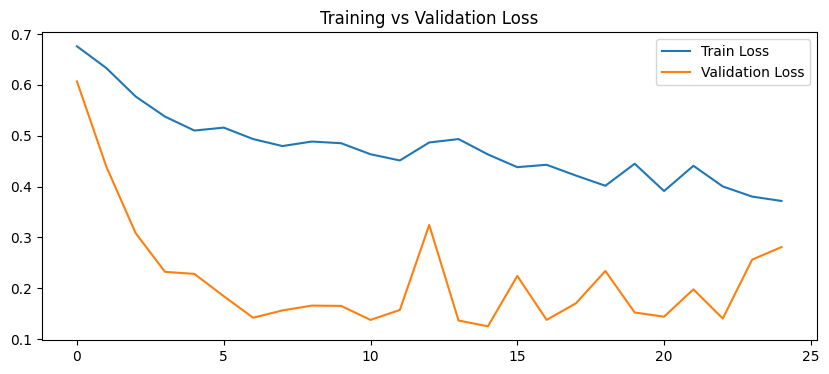

In [86]:
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

## Plot recession probabilities over time

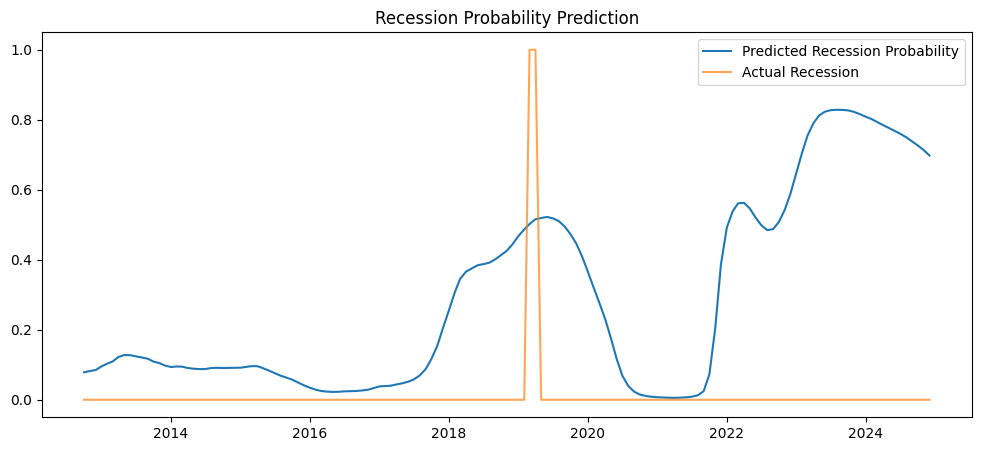

In [87]:
plt.figure(figsize=(12, 5))
plt.plot(dates_test, y_prob, label="Predicted Recession Probability")
plt.plot(dates_test, y_test, label="Actual Recession", alpha=0.7)
plt.title("Recession Probability Prediction")
plt.legend()
plt.show()

# Limitations

While the model demonstrates the ability to detect macroeconomic patterns associated with recessions, several limitations should be considered when interpreting the results.

## 1. Extreme Class Imbalance
Recessions are rare events in the dataset. The test set contains only a very small number of recession observations, which makes evaluation metrics unstable and sensitive to small prediction changes. This also explains the low precision for the recession class.

## 2. Limited Feature Set
The model only uses a small number of macroeconomic indicators. Important predictors commonly used in recession models—such as credit spreads, consumer sentiment, housing indicators, or short-term Treasury yields—are not included. This limits the model's ability to capture the full range of economic signals.

## 3. Single Train/Test Split
The model is evaluated using a single chronological train/test split. Although this avoids data leakage, it may not fully represent model performance across different economic regimes. Walk-forward validation or time-series cross-validation could provide a more robust evaluation.

## 4. Structural Changes in the Economy
Macroeconomic relationships can change over time due to policy shifts, financial innovation, or structural changes in the global economy. Models trained on historical data may not fully capture future economic dynamics.

## 5. Small Neural Network Architecture
The LSTM architecture used in this project is relatively simple and may not fully exploit the complexity of macroeconomic time-series data. Alternative architectures or additional hyperparameter tuning could potentially improve performance.

## 6. Forecast Horizon Assumption
The model is designed to predict recessions **12 months ahead**. While this horizon is common in macroeconomic forecasting, different time horizons may reveal different predictive relationships.

Because of these limitations, the model should be interpreted as an **experimental macroeconomic forecasting framework** rather than a definitive recession prediction tool.

# Conclusion

This project developed a macroeconomic forecasting model to estimate the **probability of a recession 12 months ahead** using key indicators from the FRED database. Raw macroeconomic variables were transformed into **year-over-year changes and spreads** to remove long-term trends and better capture cyclical dynamics in the economy.

A multivariate **LSTM model** was implemented to learn temporal relationships across inflation, industrial production growth, monetary policy changes, labor market conditions, and financial market expectations. By structuring the data into **12-month historical sequences**, the model was able to incorporate lagged macroeconomic effects that often precede economic downturns.

Model evaluation indicates that the system successfully **detects recession signals**, achieving high recall for recession events. However, due to the extremely **imbalanced nature of recession data**, the model produces a relatively high number of false positives. This behavior reflects the trade-off between **early recession detection and prediction precision**, which is common in macroeconomic forecasting models.

Despite these limitations, the model demonstrates that combining macroeconomic indicators with sequence-based learning can generate **forward-looking recession probability estimates**. Such models can serve as **early warning systems**, helping policymakers, investors, and analysts monitor potential economic downturns.

Future improvements could include incorporating additional macro-financial indicators, applying walk-forward validation, optimizing probability thresholds, and experimenting with alternative sequence models to improve prediction stability and reduce false alarms.